In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [ ]:
# Time Series Forecasting with sktime Transformer forecaster
# This notebook uses sktime APIs only (no direct torch model code)
# Model: LTSFTransformerForecaster

In [ ]:
# Optional dependency install
# !pip install -U sktime torch

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.datasets import load_airline
from sktime.forecasting.ltsf import LTSFTransformerForecaster
from sktime.performance_metrics.forecasting import mean_absolute_error, mean_absolute_percentage_error

In [24]:
print("Loading data...")
airline = load_airline()
print("Dataset shape:", airline.shape)
print(airline.head())
airline.tail()

Loading data...
Dataset shape: (144,)
Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64


Period
1960-08    606.0
1960-09    508.0
1960-10    461.0
1960-11    390.0
1960-12    432.0
Freq: M, Name: Number of airline passengers, dtype: float64

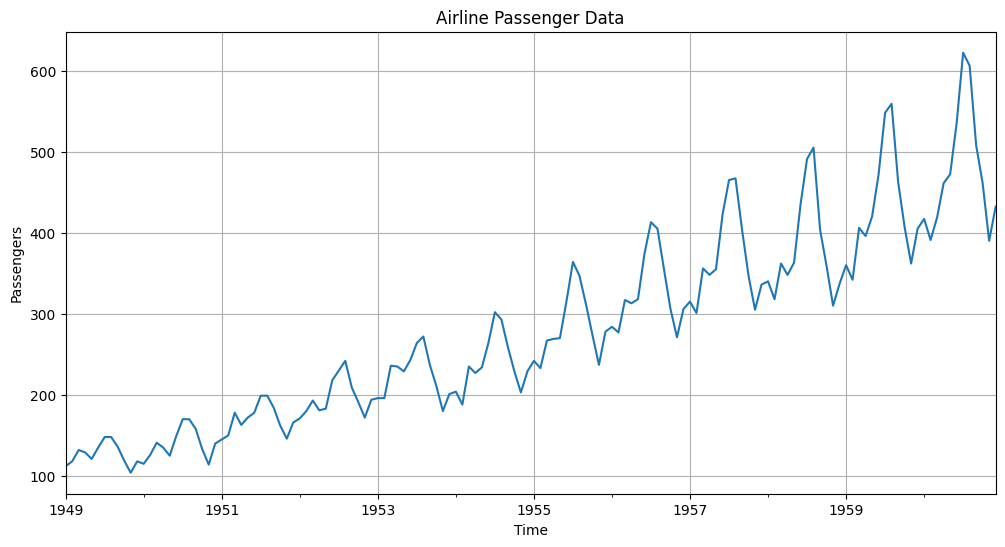

In [15]:
plt.figure(figsize=(12, 6))
airline.plot()
plt.title('Airline Passenger Data')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()

In [48]:
split_point = int(len(airline) * 0.8)
y_train, y_test = airline.iloc[:split_point], airline.iloc[split_point:]

# Log transform + standardization for stable deep model training
y_train_log = np.log1p(y_train)
y_train_log_mu = y_train_log.mean()
y_train_log_std = y_train_log.std()
y_train_scaled = (y_train_log - y_train_log_mu) / y_train_log_std

In [49]:
# Train with 12-step horizon (seasonality), infer with one-step rolling
train_pred_len = 12
fit_fh = np.arange(1, train_pred_len + 1)
fh_step = np.array([1])
seq_len = 36
context_len = 12
print(f"Train={len(y_train)}, Test={len(y_test)}, seq_len={seq_len}, train_pred_len={train_pred_len}")

Train=115, Test=29, seq_len=36, train_pred_len=12


In [50]:
# Main transformer forecaster (monthly data)
transformer_fcst = LTSFTransformerForecaster(
    seq_len=seq_len,
    context_len=context_len,
    pred_len=train_pred_len,
    num_epochs=200,
    batch_size=8,
    d_model=128,
    n_heads=8,
    d_ff=256,
    e_layers=2,
    d_layers=1,
    dropout=0.1,
    lr=0.0005,
    freq="ME"
    )

In [52]:
print("Training LTSFTransformer...")
transformer_fcst.fit(y_train_scaled, fh=fit_fh)

# One-step rolling forecast on test horizon
y_pred_vals = []
for idx in y_test.index:
    next_pred_scaled = transformer_fcst.predict(fit_fh).iloc[0]
    next_pred_log = next_pred_scaled * y_train_log_std + y_train_log_mu
    y_pred_vals.append(np.expm1(next_pred_log))

    y_obs_scaled = (np.log1p(y_test.loc[[idx]]) - y_train_log_mu) / y_train_log_std
    transformer_fcst.update(y_obs_scaled, update_params=False)

y_pred_transformer = pd.Series(y_pred_vals, index=y_test.index, name=y_test.name)

Training LTSFTransformer...


In [53]:
mae_transformer = mean_absolute_error(y_test, y_pred_transformer)
mape_transformer = mean_absolute_percentage_error(y_test, y_pred_transformer)

print(f"Transformer MAE: {mae_transformer:.2f}, MAPE: {mape_transformer:.2%}")

Transformer MAE: 52.28, MAPE: 11.58%


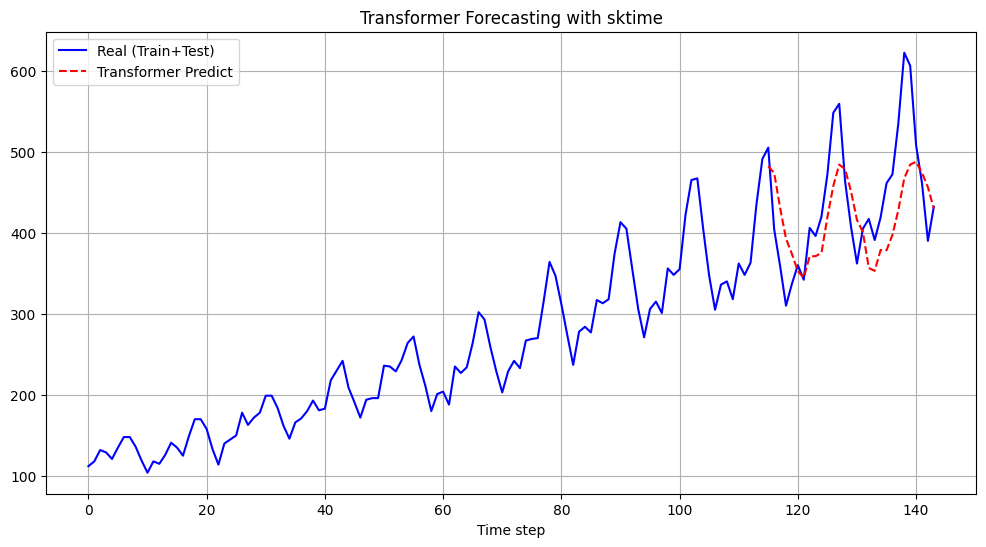

In [56]:
# Use numeric x-axis to avoid PeriodIndex plotting issues
y_real = pd.concat([y_train, y_test])
x_real = np.arange(len(y_real))
x_test = np.arange(len(y_train), len(y_train) + len(y_test))

# Align prediction to the test horizon
y_pred_transformer_aligned = y_pred_transformer.reindex(y_test.index)

plt.figure(figsize=(12, 6))
plt.plot(x_real, y_real.values, "b-", label="Real (Train+Test)")
plt.plot(x_test, y_pred_transformer_aligned.values, "r--", label="Transformer Predict")
plt.title("Transformer Forecasting with sktime")
plt.xlabel("Time step")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
print("Summary:")
print(f"LTSFTransformer -> MAE={mae_transformer:.2f}, MAPE={mape_transformer:.2%}")

Summary:
LTSFTransformer -> MAE=52.28, MAPE=11.58%
